<a href="https://colab.research.google.com/github/lewinskie254/Remote-Sensing/blob/main/main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [36]:
import os
from pathlib import Path
import kagglehub
import segmentation_models_pytorch as sm
from segmentation_models_pytorch.encoders import get_preprocessing_fn
from image_prep import fetch_images, save_patches_and_masks, get_patches
import os
from dotenv import load_dotenv
from huggingface_hub import login
import torch
from segmentation_loader import SegmentationDataset
from torch.utils.data import DataLoader
import torch.optim as optim
import torch.nn as nn
from tqdm import tqdm
from partial_cross_entropy import PartialBCELoss
import matplotlib.pyplot as plt

In [37]:
# Download latest version
path = kagglehub.dataset_download(
    "balraj98/massachusetts-buildings-dataset"
)

print("Dataset downloaded to:", path)

Using Colab cache for faster access to the 'massachusetts-buildings-dataset' dataset.
Dataset downloaded to: /kaggle/input/massachusetts-buildings-dataset


In [38]:
dataset_path = Path("/root/.cache/kagglehub/datasets/balraj98/massachusetts-buildings-dataset/versions/2")

print("Contents of the dataset root:")
for item in dataset_path.iterdir():
    print(item.name)

Contents of the dataset root:
metadata.csv
label_class_dict.csv
tiff
png


In [39]:
dataset_root =  Path("/root/.cache/kagglehub/datasets/balraj98/massachusetts-buildings-dataset/versions/2/")

In [40]:
train_path = dataset_root / "png" / "train"
train_label_path = dataset_root / "png" / "train_labels"

test_path = dataset_root / "png" / "test"
test_label_path = dataset_root / "png" / "test_labels"

In [41]:
SIZE_X = 256
SIZE_Y = 256


train_images = fetch_images(str(train_path))
train_masks = fetch_images(str(train_label_path), False)

test_images = fetch_images(str(test_path))
test_masks = fetch_images(str(test_label_path), False)


Loading Images: 100%|██████████| 10/10 [00:00<00:00, 38.15it/s]


In [42]:
train_patches = [ get_patches(train_images[i], train_masks[i], (SIZE_X, SIZE_Y), SIZE_X) for i in tqdm(range(len(train_images)))] #default size 256
test_patches = [ get_patches(test_images[i], test_masks[i], (SIZE_X, SIZE_Y), SIZE_X) for i in tqdm(range(len(test_images)))] #default size 256


100%|██████████| 10/10 [00:00<00:00, 363.52it/s]


In [43]:
print(train_patches[0][0].shape)



save_patches_and_masks(train_patches, image_dir='patches/train', mask_dir='patches/train_labels')
save_patches_and_masks(test_patches, image_dir='patches/test', mask_dir='patches/test_labels')


(6, 6, 1, 256, 256, 3)


Saving patches: 100%|██████████| 137/137 [00:00<00:00, 224.19it/s]


Successfully saved all image and mask patches.


Saving patches: 100%|██████████| 10/10 [00:00<00:00, 208.24it/s]

Successfully saved all image and mask patches.


In [44]:
load_dotenv()
TOKEN = os.environ['HF_TOKEN']

login(token=TOKEN)


#%%
BACKBONE = 'resnet34'

preprocess_input = get_preprocessing_fn(BACKBONE)

model = sm.Unet(
    encoder_name=BACKBONE,
    encoder_weights='imagenet',
    in_channels=3,
    classes=1,
)


Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


In [45]:
X_train_path = '/content/patches/train'
y_train_path = '/content/patches/train_labels'

print(f"Checking X path: {os.path.exists(X_train_path)}")
print(f"Checking Y path: {os.path.exists(y_train_path)}")

Checking X path: True
Checking Y path: True


In [46]:
X_train = fetch_images(X_train_path)
y_train = fetch_images(y_train_path, False)

Loading Images: 100%|██████████| 137/137 [00:00<00:00, 2749.35it/s]


In [47]:
dataset = SegmentationDataset(X_train, y_train, preprocess_input)
loader = DataLoader(dataset, batch_size=16, shuffle=True, num_workers=0)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

In [48]:
optimizer = optim.Adam(model.parameters(), lr=1e-4)
criterion = PartialBCELoss()

In [49]:
loss_track = []

epochs = 100
model.train()

for epoch in range(epochs):
    epoch_loss = 0
    progress_bar = tqdm(loader, desc=f"Epoch {epoch+1}/{epochs}")

    for images, masks in progress_bar:
        images = images.to(device)
        masks = masks.to(device)

        # Zero the gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, masks)

        # Backward pass
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        loss_track.append(loss.item())
        progress_bar.set_postfix(loss=loss.item())

    print(f"Epoch {epoch+1} completed. Average Loss: {epoch_loss / len(loader):.4f}")


Epoch 1/100: 100%|██████████| 9/9 [00:02<00:00,  3.99it/s, loss=0.673]


Epoch 1 completed. Average Loss: 0.6983


Epoch 2/100: 100%|██████████| 9/9 [00:02<00:00,  4.07it/s, loss=0.584]


Epoch 2 completed. Average Loss: 0.6040


Epoch 3/100: 100%|██████████| 9/9 [00:02<00:00,  4.02it/s, loss=0.514]


...

Epoch 98 completed. Average Loss: 0.0861


Epoch 99/100: 100%|██████████| 9/9 [00:02<00:00,  3.97it/s, loss=0.113]


Epoch 99 completed. Average Loss: 0.0860


Epoch 100/100: 100%|██████████| 9/9 [00:02<00:00,  4.00it/s, loss=0.114]

Epoch 100 completed. Average Loss: 0.0847


In [50]:
X_test_path = '/content/patches/test'
y_test_path = '/content/patches/test_labels'

print(f"Checking X path: {os.path.exists(X_train_path)}")
print(f"Checking Y path: {os.path.exists(y_train_path)}")

Checking X path: True
Checking Y path: True


In [51]:
X_test = fetch_images(X_test_path)
y_test = fetch_images(y_test_path, False)

test_dataset = SegmentationDataset(
    X_test,
    y_test,
    preprocess_input
)

test_loader = DataLoader(
    test_dataset,
    batch_size=16,
    shuffle=False
)

Loading Images: 100%|██████████| 10/10 [00:00<00:00, 2352.25it/s]


In [52]:
def calculate_metrics(preds, targets, threshold=0.5, ignore_index=255):

    preds = torch.sigmoid(preds)
    preds = (preds > threshold).float()

    valid = (targets != ignore_index)

    targets = targets.clone()
    targets[~valid] = 0
    targets = (targets > 0.5).float()

    preds = preds[valid]
    targets = targets[valid]

    intersection = (preds * targets).sum()

    union = preds.sum() + targets.sum() - intersection

    iou = (intersection + 1e-7) / (union + 1e-7)

    dice = (2 * intersection + 1e-7) / (
        preds.sum() + targets.sum() + 1e-7
    )

    return iou.item(), dice.item()

In [53]:
model.eval()

total_iou = 0
total_dice = 0
num_batches = 0

with torch.no_grad():

    for images, masks in test_loader:

        images = images.to(device)
        masks = masks.to(device)

        outputs = model(images)

        iou, dice = calculate_metrics(outputs, masks)

        total_iou += iou
        total_dice += dice
        num_batches += 1

print(f"Mean IoU : {total_iou / num_batches:.4f}")
print(f"Mean Dice: {total_dice / num_batches:.4f}")

Mean IoU : 0.3751
Mean Dice: 0.5456


In [54]:
model.eval()
outputs = model(images)



In [55]:

def visualize_predictions(model, loader, device, num_images=5):
    model.eval()

    shown = 0

    with torch.no_grad():

        for images, masks in loader:

            images = images.to(device)

            outputs = model(images)
            preds = torch.sigmoid(outputs)
            preds = (preds > 0.5).float()

            images = images.cpu()
            masks = masks.cpu()
            preds = preds.cpu()

            batch_size = images.size(0)

            for i in range(batch_size):

                if shown >= num_images:
                    return

                image = images[i].permute(1, 2, 0).numpy()

                # If preprocessing normalized the image,
                # rescale it for display.
                image = image - image.min()
                image = image / (image.max() + 1e-8)

                gt = masks[i].squeeze().numpy()
                pred = preds[i].squeeze().numpy()

                fig, ax = plt.subplots(1, 3, figsize=(15,5))

                ax[0].imshow(image)
                ax[0].set_title("Input Image")
                ax[0].axis("off")

                ax[1].imshow(gt, cmap="gray")
                ax[1].set_title("Ground Truth")
                ax[1].axis("off")

                ax[2].imshow(pred, cmap="gray")
                ax[2].set_title("Prediction")
                ax[2].axis("off")

                plt.show()

                shown += 1

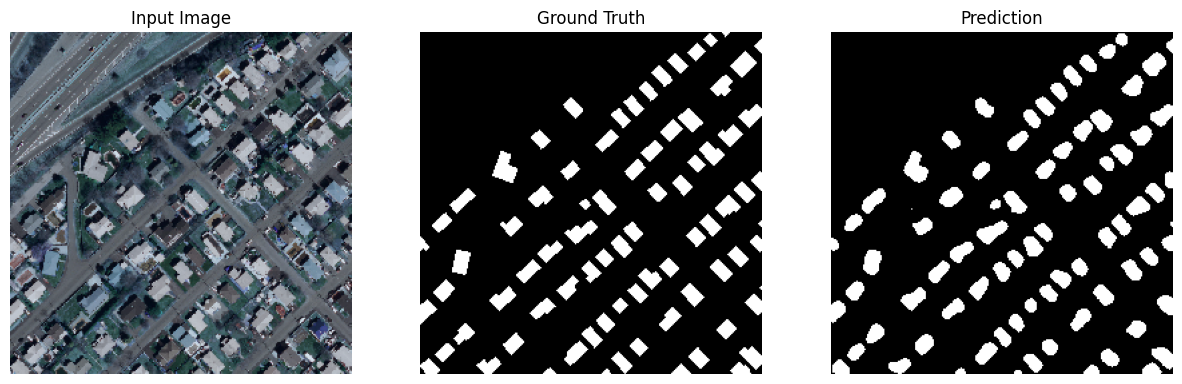

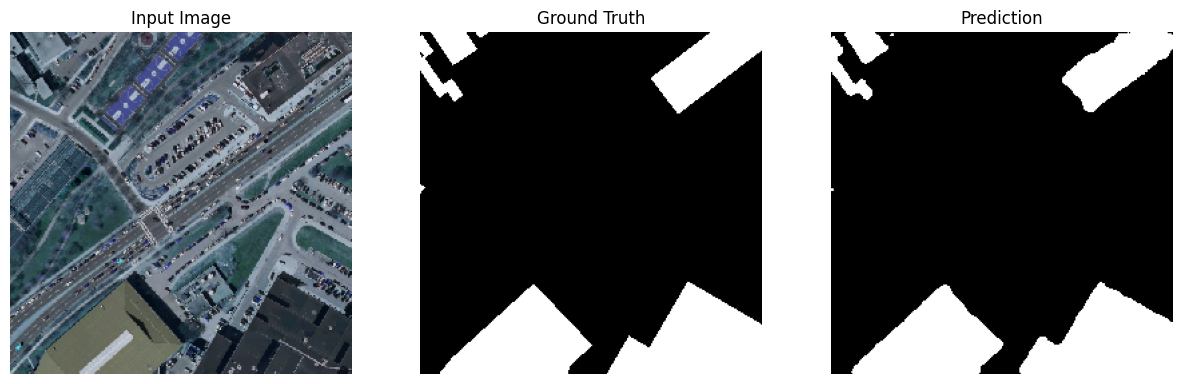

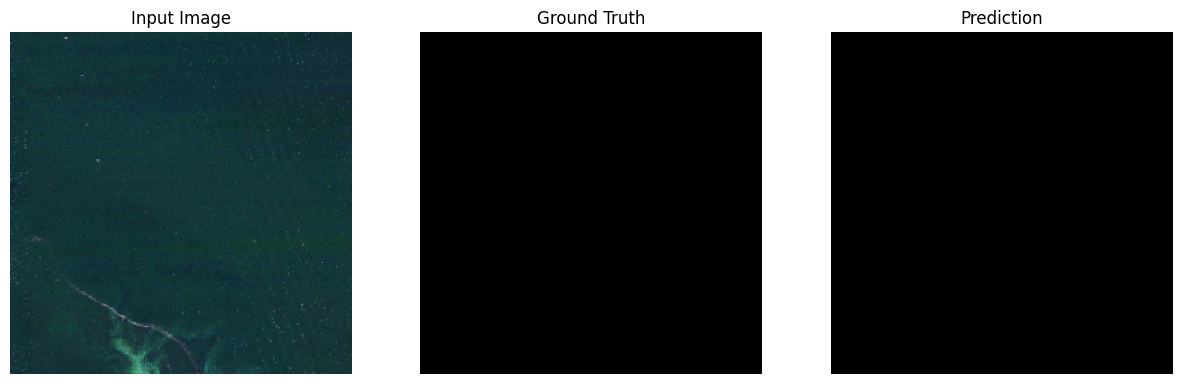

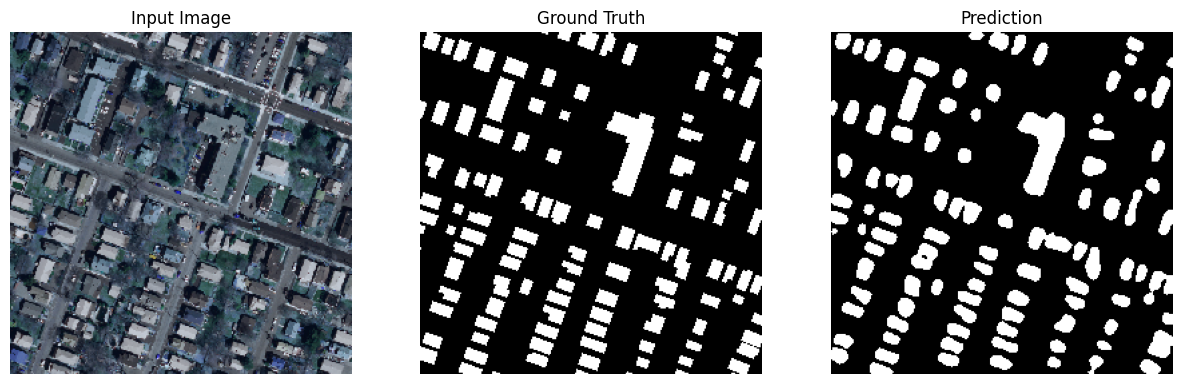

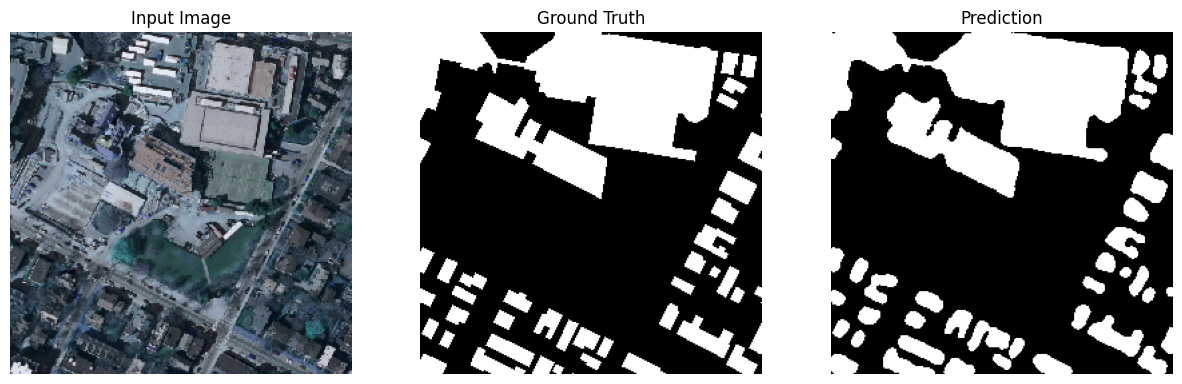

In [56]:
visualize_predictions(model, loader, device, num_images=5)